In [2]:
import matplotlib.pyplot as plt
from phoxipy import PhoXiSensor
import datetime

time = datetime.datetime.now().isoformat()
print("Time: ", time)

p = PhoXiSensor("1703005")
p.start()

frame = p.read()
plt.title("Intensity Image")
plt.imshow(frame.color.data)
plt.tight_layout()
plt.show()
plt.imsave(f"intensity_image{time}.png", frame.color.data)
p.stop()


ModuleNotFoundError: No module named 'phoxipy'

In [10]:
import PIL.Image as Image
import numpy as np
from decluttering.data.utils.detic_dataloader import DeticDataloader
import matplotlib.pyplot as plt

detic = DeticDataloader()
detic.create()
detic.default_vocab()

Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy


In [11]:

# im_frame1 = Image.open('/home/justinyu/multicable-decluttering/decluttering/scripts/test/intensity_image.png')
# im_frame1 = im_frame1.resize((640, 480))
im_frame1 = frame.color.data
np_frame1 = np.array(im_frame1)

# remove alpha channel
np_frame1 = np_frame1[0:650, :, :3]


Inference time:  0.06474828720092773


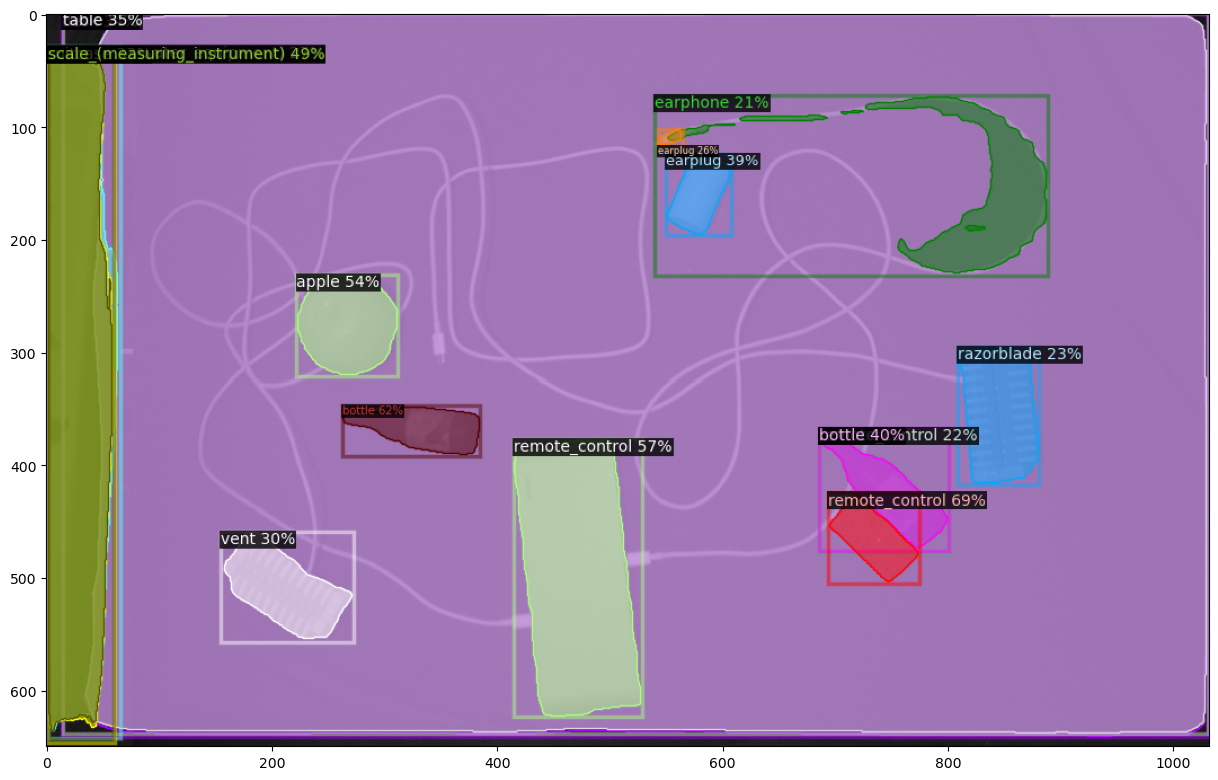

In [14]:

out = detic.predict(np_frame1)
output_im = out['vis'].get_image()
# print(output_im.shape)

plt.figure(figsize=(15, 15))
plt.imshow(output_im) 
plt.imsave(f"output_image{time}.png", output_im)


Number of masks before filtering torch.Size([17, 1, 650, 1032])
Area of masks before filtering tensor([  2996,   3587,  21590,   4310,   6233,   2538,    367,  34089,   1648,
           983,    877, 614527, 612480,   7050,   5753,   6227,   1727],
       device='cuda:0')
torch.Size([12, 1, 650, 1032])
Number of masks after filtering:  12
Area of masks after filtering tensor([2996, 3587, 4310, 6233, 2538, 1648,  983,  877, 7050, 5753, 6227, 1727],
       device='cuda:0')


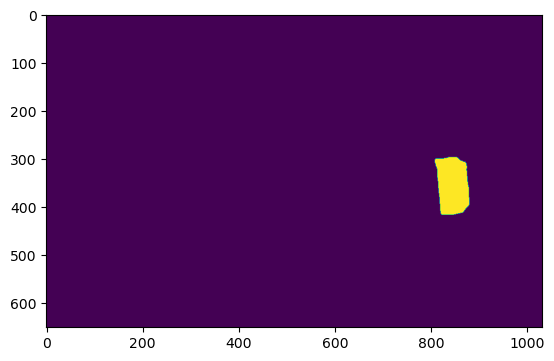

torch.Size([1, 650, 1032])
tensor(7050, device='cuda:0')


In [9]:
import torch
num_masks = out['masks'].shape[0]
print("Number of masks before filtering", out['masks'].shape)
print("Area of masks before filtering", torch.sum(out['masks'], dim = (1,2,3)))

def filter_mask_by_area(masks, max_area = 10000, min_area = 500):
    """
    Filter masks by area
    """
    mask_areas = torch.sum(masks, dim = (1,2,3))
    mask_areas = mask_areas.cpu().numpy()
    mask_areas = mask_areas.reshape(-1)
    masks_filtered = masks[(mask_areas < max_area) & (min_area < mask_areas)]
    return masks_filtered

def get_largest_mask(masks):
    sorted, indices = torch.sort(torch.sum(masks, dim = (1,2,3)), descending=True)
    return masks[indices[0]]

filtered_areas = filter_mask_by_area(out['masks'])
print(filtered_areas.shape)
num_masks = filtered_areas.shape[0]
print("Number of masks after filtering: ", num_masks)
print("Area of masks after filtering", torch.sum(filtered_areas, dim = (1,2,3)))
# for i in num_masks:
#     plt.imshow(out['masks'][i])
#     plt.show()

plt.imshow(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())
plt.show()

# sorted, indices = torch.sort(torch.sum(filtered_areas, dim = (1,2,3)), descending=True)
# print(indices)

# print(sorted)

# print(torch.sum(filtered_areas, dim = (1,2,3))[indices[0]])
print(get_largest_mask(filtered_areas).shape)
print(torch.sum(get_largest_mask(filtered_areas)))

In [10]:
# plt.imshow(filtered_areas[4].permute((1,2,0)).squeeze(-1).cpu().numpy())
# plt.show()

(355.769219858156, 845.6131914893617)


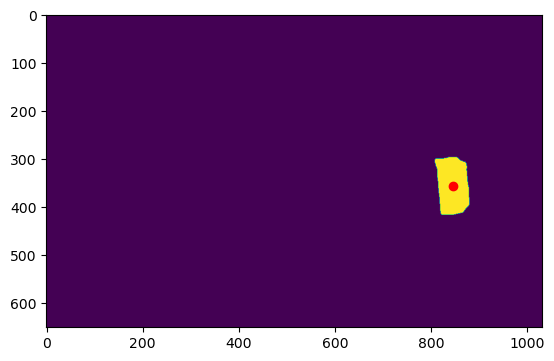

In [11]:
import numpy as np
from scipy.ndimage import center_of_mass

def find_center_of_mass(binary_mask):
    """
    Find the center of mass of pixels given a binary mask image.
    
    Parameters:
    binary_mask (numpy.ndarray): A 2D numpy array representing the binary mask image.

    Returns:
    tuple: The (row, column) coordinates of the center of mass.
    """
    # Ensure the input is a binary mask
    binary_mask = np.asarray(binary_mask, dtype=bool)
    
    # Calculate the center of mass
    center = center_of_mass(binary_mask)
    
    return center

center = find_center_of_mass(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())

print(center)

# plot with center
plt.imshow(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())
plt.scatter(center[1], center[0], c='r')


In [12]:
out['boxes'][0]

height = abs(out['boxes'][0][0] - out['boxes'][0][1])
print(height)
width = abs(out['boxes'][0][2] - out['boxes'][0][3])
print(width)

if height > width:
    print('vertical')
else:
    print('horizontal')

267.3833
267.9655
horizontal


The oriented bounding box is: ((846.8967895507812, 356.016357421875), (119.4892807006836, 64.83891296386719), 83.72270965576172)


/tmp/ipykernel_4102448/302404812.py:42: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box)


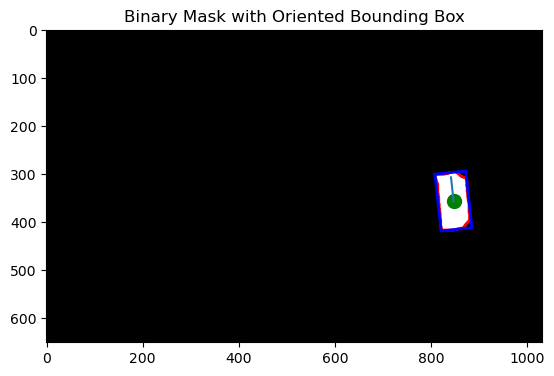

-0.10934033784191907
-0.9940043714796303


In [13]:
import cv2
import numpy as np

def get_oriented_bounding_box(binary_mask):
    """
    Fit the tightest oriented bounding box around a 2D binary mask.
    
    Parameters:
    binary_mask (numpy.ndarray): A 2D numpy array representing the binary mask image.
    
    Returns:
    tuple: The (center (x, y), (width, height), angle of rotation) of the bounding box.
    """
    # Ensure the input is a binary mask
    binary_mask = np.asarray(binary_mask, dtype=np.uint8)
    
    # Find contours in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Get the largest contour, assuming the mask is connected
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Get the minimum area bounding rectangle
    rect = cv2.minAreaRect(largest_contour)
    
    return rect, largest_contour


rect, contour = get_oriented_bounding_box(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())
print(f"The oriented bounding box is: {rect}")

def plot_mask_with_bbox(binary_mask, rect, contour):
    """
    Plot the binary mask with the oriented bounding box.
    
    Parameters:
    binary_mask (numpy.ndarray): A 2D numpy array representing the binary mask image.
    rect (tuple): The (center (x, y), (width, height), angle of rotation) of the bounding box.
    contour (numpy.ndarray): Contour of the largest component in the binary mask.
    """
    box = cv2.boxPoints(rect)
    box = np.int0(box)

    angle = rect[2]
    if rect[1][0] > rect[1][1]:
        angle = angle + 90
    
    plt.figure()
    plt.imshow(binary_mask, cmap='gray')
    plt.plot(contour[:, 0, 0], contour[:, 0, 1], 'r', linewidth=2)
    plt.plot(*zip(*np.vstack([box, box[0]])), 'b-', linewidth=2)
    plt.scatter(rect[0][0], rect[0][1], color='green', s=100)
    plt.plot([rect[0][0], rect[0][0]-50*np.sin(np.radians(angle))], [rect[0][1], rect[0][1]+50*np.cos(np.radians(angle))])
    plt.title("Binary Mask with Oriented Bounding Box")
    plt.show()

plot_mask_with_bbox(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy(), rect, contour)

center = np.array(rect[0])
angle = rect[2]
if rect[1][0] > rect[1][1]:
    angle = angle + 90
    
print(-np.sin(np.radians(angle)))
print(np.cos(np.radians(angle)))


In [14]:
from decluttering.deprecated.push_through_backup2 import get_poi_and_vec_for_push, perform_push_through, perform_pindown, perform_pick_away, perform_point_grasp, drop_in_bin
from decluttering.deprecated.demopipeline import DemoPipeline

def initialize_pipeline(logLevel):
    pipeline = DemoPipeline(viz=False, loglevel=logLevel, initialize_iface=True)
    pipeline.iface.open_grippers()
    pipeline.iface.sync()
    pipeline.iface.home()
    pipeline.iface.sync()
    return pipeline

pipeline = initialize_pipeline('DEBUG')
pipeline.iface.home()
pipeline.iface.sync()
pipeline.iface.open_grippers()
pipeline.iface.sync()

print("Angle is: ", angle)

perform_point_grasp(center, np.radians(angle), pipeline)

# pipeline.iface.home()
# pipeline.iface.sync()

Directory 'logs_2024-07-11_14-49-05' created
./logs/full_rollouts/logs_2024-07-11_14-49-05


/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


move joints
move joints
Angle is:  173.72270965576172
[846.89678955 356.01635742]
Using right arm


AttributeError: 'Interface' object has no attribute 'cam'